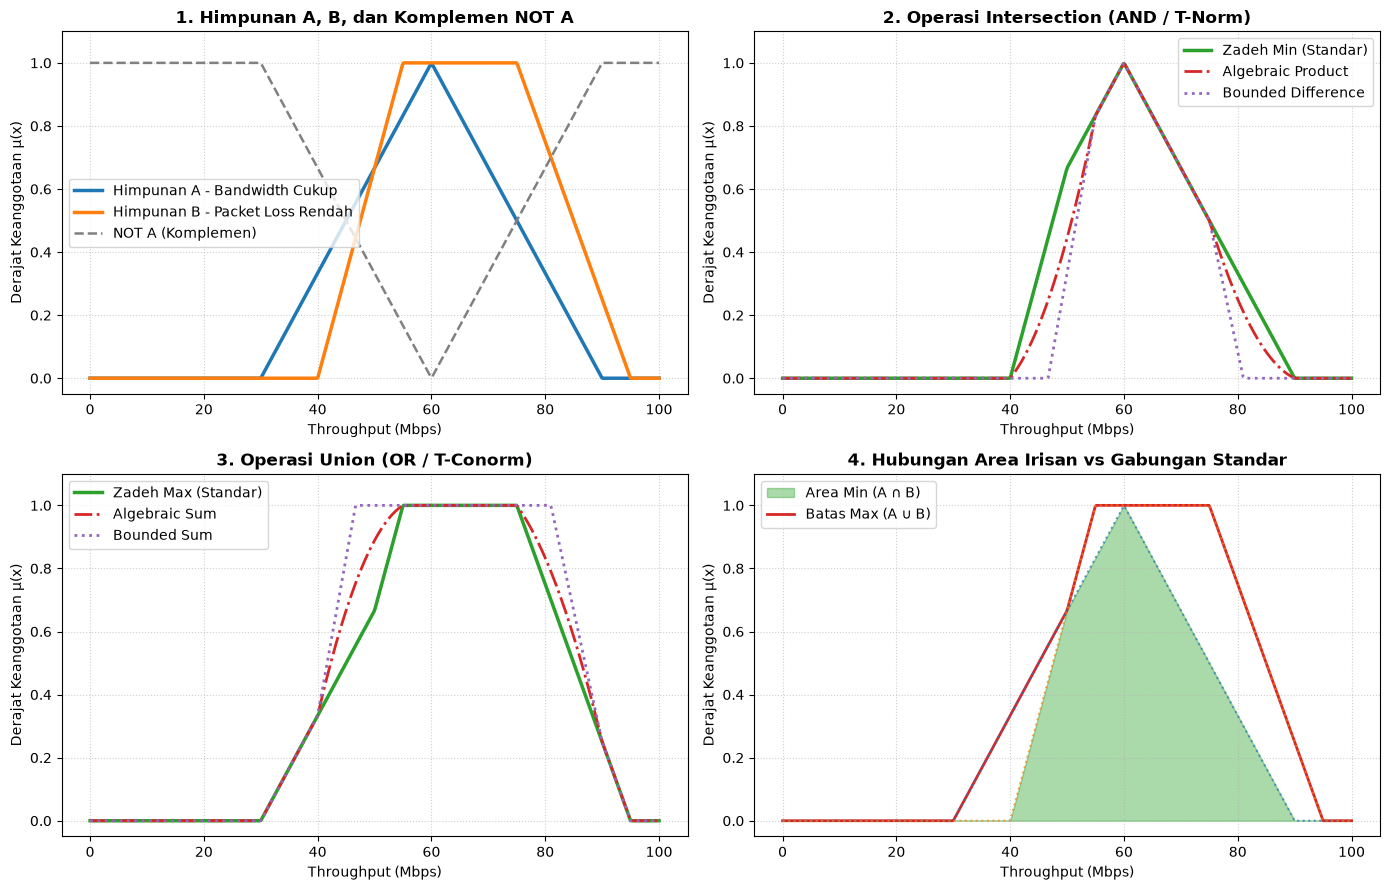

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#IMPLEMENTASI OPERATOR T-NORM (AND)

def tnorm_min(mu_a, mu_b):
    """Zadeh Min: min(A, B)"""
    return np.minimum(mu_a, mu_b)


def tnorm_product(mu_a, mu_b):
    """Algebraic Product: A * B"""
    return mu_a * mu_b


def tnorm_bounded_diff(mu_a, mu_b):
    """Bounded Difference: max(0, A + B - 1)"""
    return np.maximum(0.0, mu_a + mu_b - 1.0)


#IMPLEMENTASI OPERATOR T-CONORM (OR)

def tconorm_max(mu_a, mu_b):
    """Zadeh Max: max(A, B)"""
    return np.maximum(mu_a, mu_b)


def tconorm_algebraic_sum(mu_a, mu_b):
    """Algebraic Sum: A + B - (A * B)"""
    return mu_a + mu_b - (mu_a * mu_b)


def tconorm_bounded_sum(mu_a, mu_b):
    """Bounded Sum: min(1, A + B)"""
    return np.minimum(1.0, mu_a + mu_b)


#IMPLEMENTASI KOMPLEMEN (NOT)

def fuzzy_not(mu):
    """Zadeh Complement: 1 - mu"""
    return 1.0 - mu


#IMULASI DUA FUNGSI KEANGGOTAAN

x = np.linspace(0, 100, 500)


# Himpunan A: Ketersediaan Bandwidth Cukup
# Model Segitiga [30, 60, 90]

mu_a = np.maximum(
    0.0,
    np.minimum(
        (x - 30.0) / (60.0 - 30.0),
        (90.0 - x) / (90.0 - 60.0)
    )
)


# Himpunan B: Packet Loss Rendah
# Model Trapesium [40, 55, 75, 95]

mu_b = np.maximum(
    0.0,
    np.minimum(
        np.minimum(
            (x - 40.0) / (55.0 - 40.0),
            1.0
        ),
        (95.0 - x) / (95.0 - 75.0)
    )
)


#VISUALISASI KOMPARASI OPERASI

fig, axes = plt.subplots(2, 2, figsize=(14, 9))



# PANEL 1: HIMPUNAN A, B DAN NOT A

axes[0, 0].plot(
    x,
    mu_a,
    label='Himpunan A - Bandwidth Cukup',
    color='#1f77b4',
    linewidth=2.5
)

axes[0, 0].plot(
    x,
    mu_b,
    label='Himpunan B - Packet Loss Rendah',
    color='#ff7f0e',
    linewidth=2.5
)

axes[0, 0].plot(
    x,
    fuzzy_not(mu_a),
    label='NOT A (Komplemen)',
    color='gray',
    linestyle='--',
    linewidth=1.8
)

axes[0, 0].set_title(
    '1. Himpunan A, B, dan Komplemen NOT A',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Throughput (Mbps)')
axes[0, 0].set_ylabel('Derajat Keanggotaan μ(x)')

axes[0, 0].set_ylim(-0.05, 1.1)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()


# PANEL 2: INTERSECTION / AND / T-NORM

axes[0, 1].plot(
    x,
    tnorm_min(mu_a, mu_b),
    label='Zadeh Min (Standar)',
    color='#2ca02c',
    linewidth=2.5
)

axes[0, 1].plot(
    x,
    tnorm_product(mu_a, mu_b),
    label='Algebraic Product',
    color='#d62728',
    linestyle='-.',
    linewidth=2
)

axes[0, 1].plot(
    x,
    tnorm_bounded_diff(mu_a, mu_b),
    label='Bounded Difference',
    color='#9467bd',
    linestyle=':',
    linewidth=2
)

axes[0, 1].set_title(
    '2. Operasi Intersection (AND / T-Norm)',
    fontweight='bold'
)

axes[0, 1].set_xlabel('Throughput (Mbps)')
axes[0, 1].set_ylabel('Derajat Keanggotaan μ(x)')

axes[0, 1].set_ylim(-0.05, 1.1)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()


# PANEL 3: UNION / OR / T-CONORM

axes[1, 0].plot(
    x,
    tconorm_max(mu_a, mu_b),
    label='Zadeh Max (Standar)',
    color='#2ca02c',
    linewidth=2.5
)

axes[1, 0].plot(
    x,
    tconorm_algebraic_sum(mu_a, mu_b),
    label='Algebraic Sum',
    color='#d62728',
    linestyle='-.',
    linewidth=2
)

axes[1, 0].plot(
    x,
    tconorm_bounded_sum(mu_a, mu_b),
    label='Bounded Sum',
    color='#9467bd',
    linestyle=':',
    linewidth=2
)

axes[1, 0].set_title(
    '3. Operasi Union (OR / T-Conorm)',
    fontweight='bold'
)

axes[1, 0].set_xlabel('Throughput (Mbps)')
axes[1, 0].set_ylabel('Derajat Keanggotaan μ(x)')

axes[1, 0].set_ylim(-0.05, 1.1)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()



# PANEL 4: PERBANDINGAN AREA MIN VS MAX

axes[1, 1].fill_between(
    x,
    tnorm_min(mu_a, mu_b),
    color='#2ca02c',
    alpha=0.4,
    label='Area Min (A ∩ B)'
)

axes[1, 1].plot(
    x,
    tconorm_max(mu_a, mu_b),
    color='#d62728',
    linewidth=2,
    label='Batas Max (A ∪ B)'
)

axes[1, 1].plot(
    x,
    mu_a,
    color='#1f77b4',
    linestyle=':',
    alpha=0.7
)

axes[1, 1].plot(
    x,
    mu_b,
    color='#ff7f0e',
    linestyle=':',
    alpha=0.7
)

axes[1, 1].set_title(
    '4. Hubungan Area Irisan vs Gabungan Standar',
    fontweight='bold'
)

axes[1, 1].set_xlabel('Throughput (Mbps)')
axes[1, 1].set_ylabel('Derajat Keanggotaan μ(x)')

axes[1, 1].set_ylim(-0.05, 1.1)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()


# MENAMPILKAN GRAFIK

plt.tight_layout()

plt.savefig(
    'operasi_himpunan_fuzzy_bandwidth.png',
    dpi=300
)

plt.show()

In [5]:
#PENGUJIAN OPERASI NUMERIK

test_values = [35, 50, 65, 80]

print()
print("------------------------------------------------------------------------")
print("HASIL PENGUJIAN OPERASI FUZZY")
print("------------------------------------------------------------------------")

print(
    f"{'Throughput':<12}"
    f"{'μA':<10}"
    f"{'μB':<10}"
    f"{'Min':<10}"
    f"{'Product':<10}"
    f"{'Max':<10}"
    f"{'Alg. Sum':<10}"
)

print("-" * 72)

for nilai in test_values:

    # Menghitung derajat A
    mu_a_uji = float(
        np.interp(nilai, x, mu_a)
    )

    # Menghitung derajat B
    mu_b_uji = float(
        np.interp(nilai, x, mu_b)
    )

    # Operasi AND
    hasil_min = float(
        tnorm_min(mu_a_uji, mu_b_uji)
    )

    hasil_product = float(
        tnorm_product(mu_a_uji, mu_b_uji)
    )

    # Operasi OR
    hasil_max = float(
        tconorm_max(mu_a_uji, mu_b_uji)
    )

    hasil_sum = float(
        tconorm_algebraic_sum(
            mu_a_uji,
            mu_b_uji
        )
    )

    print(
        f"{nilai:<12}"
        f"{mu_a_uji:<10.3f}"
        f"{mu_b_uji:<10.3f}"
        f"{hasil_min:<10.3f}"
        f"{hasil_product:<10.3f}"
        f"{hasil_max:<10.3f}"
        f"{hasil_sum:<10.3f}"
    )

print("------------------------------------------------------------------------")


------------------------------------------------------------------------
HASIL PENGUJIAN OPERASI FUZZY
------------------------------------------------------------------------
Throughput  μA        μB        Min       Product   Max       Alg. Sum  
------------------------------------------------------------------------
35          0.167     0.000     0.000     0.000     0.167     0.167     
50          0.667     0.667     0.667     0.444     0.667     0.889     
65          0.833     1.000     0.833     0.833     1.000     1.000     
80          0.333     0.750     0.333     0.250     0.750     0.833     
------------------------------------------------------------------------
